# Machine Learning Lab 7 — Naïve Bayes Classification

**Name:** Hanshal Bobate  
**Section:** B  
**Roll No.:** 40  
**Batch:** B3

## Aim
To classify raisin varieties using a Gaussian Naïve Bayes model and evaluate its performance on the Raisin Grains dataset.

### Workflow
1. Import the libraries and machine-learning utilities required for classification and evaluation.
2. Load the `Raisin_Grains_Dataset.csv` dataset.
3. Perform exploratory data analysis to inspect the data, examine class distribution, study feature distributions and outliers, and visualize relationships and correlations.
4. Encode the categorical `Class` target into numeric labels.
5. Select numerical features and separate the input features (`X`) from the target (`y`).
6. Split the data into training and testing sets using stratified sampling.
7. Train a Gaussian Naïve Bayes classifier and generate predictions for the test set.
8. Compare actual and predicted labels, including their original class names.
9. Evaluate the classifier using accuracy, weighted precision, weighted recall, F1-score, a classification report, and a confusion matrix.
10. Compare training and testing accuracy.




## 1. Import Libraries

Import the libraries used throughout the notebook. NumPy and Pandas support numerical and tabular data operations, while Matplotlib and Seaborn are used to create visualizations.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Import Machine Learning Tools

Import the functions and classes required for splitting the dataset, encoding the target labels, training a Gaussian Naïve Bayes classifier, and evaluating its predictions with classification metrics and a confusion matrix.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
import tensorflow as tf
pd.set_option('display.max_columns',None)

## 3. Load the Dataset

Read the raisin dataset CSV file into a Pandas DataFrame named `df`. The remaining cells use this DataFrame for exploratory analysis and classification.

In [ ]:
df = pd.read_csv("Raisin_Grains_Dataset.csv")

## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the dataset before training the Naïve Bayes classifier. The following steps inspect the data, check data quality, examine feature distributions, and explore relationships between features and the target class.

### 3.1 Preview the Dataset

Display the first and last five records to verify that the dataset loaded correctly and to inspect the format of its rows and columns.

In [ ]:
display(df.head())
display(df.tail())

### 3.2 Understand the Dataset Structure

Check the number of rows and columns, column names, data types, non-null counts, and memory usage. This helps identify numerical features and the categorical target column.

In [ ]:
print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nDataset information:")
df.info()

### 3.3 Descriptive Statistics

Summarize the numerical columns using count, mean, standard deviation, quartiles, minimum, and maximum values. These statistics provide an initial view of feature scales and possible extreme values.

In [ ]:
display(df.describe())

### 3.4 Check Missing Values

Count missing observations in each column. A heatmap gives a visual overview of where missing values occur across the dataset.

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values in Raisin Dataset")
plt.xlabel("Columns")
plt.ylabel("Records")
plt.show()

### 3.5 Check Duplicate Records

Count exact duplicate rows. This is a data-quality check; the rows are not removed here, so the original dataset remains unchanged.

In [ ]:
print("Number of duplicate records:", df.duplicated().sum())

### 3.6 Class Distribution (Univariate Analysis)

Count the observations belonging to each raisin class. The count plot and pie chart help reveal whether the target classes are balanced.

In [ ]:
print(df["Class"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="Class", ax=axes[0])
axes[0].set_title("Raisin Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

df["Class"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[1])
axes[1].set_title("Percentage of Each Class")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

### 3.7 Numerical Feature Distributions (Univariate Analysis)

Plot histograms with KDE curves for each numerical feature. These plots show each feature’s distribution, spread, skewness, and potential multiple modes.

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Distributions of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

for column in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=column, hue="Class", kde=True, element="step", stat="density", common_norm=False)
    plt.title(f"{column} Distribution by Class")
    plt.tight_layout()
    plt.show()

### 3.8 Outlier Visualization

Use boxplots to inspect the spread of each numerical feature and identify observations beyond the whiskers. Such points are potential outliers and are not removed in this EDA step.

In [ ]:
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 3 * len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, column in zip(axes, numeric_cols):
    sns.boxplot(data=df, x=column, ax=ax)
    ax.set_title(f"Boxplot of {column}")
plt.tight_layout()
plt.show()

### 3.9 Feature Relationships with Class (Bivariate Analysis)

Compare each numerical feature across the target classes using boxplots. Differences in medians and spreads can indicate which measurements may help distinguish the classes.

In [ ]:
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 3.5 * len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, column in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="Class", y=column, ax=ax)
    ax.set_title(f"{column} by Raisin Class")
plt.tight_layout()
plt.show()

### 3.10 Pairwise Feature Relationships

A pairplot compares numerical features pairwise and colors observations by class. It can reveal clusters, correlations, and combinations of measurements that separate the classes.

In [ ]:
sns.pairplot(df, vars=numeric_cols, hue="Class", diag_kind="hist", corner=True)
plt.suptitle("Pairwise Relationships Between Numerical Features", y=1.02)
plt.show()

### 3.11 Correlation Matrix (Multivariate Analysis)

Calculate correlations between numerical features and visualize them in a heatmap. Correlation indicates the strength and direction of linear relationships; it does not imply causation.

In [ ]:
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

## 4. Encode the Target Classes

`LabelEncoder` converts the text labels in the `Class` column into integer class IDs. The new `Class_encoded` column stores those IDs, and the displayed rows let us verify the transformation.

In [ ]:
label_encoder = LabelEncoder()
df['Class_encoded'] = label_encoder.fit_transform(df['Class'])
print(df[["Class", "Class_encoded"]].head(5))

     Class  Class_encoded
0  Kecimen              1
1  Kecimen              1
2  Kecimen              1
3  Kecimen              1
4  Kecimen              1


## 5. Inspect the Class-to-Number Mapping

Print the mapping learned by the label encoder so each integer ID can be traced back to its original raisin class name.

In [ ]:
print("Class Mapping:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"{idx} : {class_name}")

Class Mapping:
0 : Besni
1 : Kecimen


## 6. Prepare Features and Target

Select numerical columns as the feature matrix `X` and use `Class_encoded` as the target vector `y`. The printed shapes show how many rows and features are being passed to the model.

In [ ]:
numerical_features = df.select_dtypes(include = np.number).columns
X = df[numerical_features]
y = df["Class_encoded"]
print("X Shape: ", X.shape)
print("y Shape: ", y.shape)

X Shape:  (900, 8)
y Shape:  (900,)


## 7. Split the Dataset into Training and Testing Sets

Split the data so 80% is used for training and 20% is held out for testing. `random_state=42` makes the split reproducible, and `stratify=y` preserves the class proportions in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

## 8. Train the Gaussian Naïve Bayes Classifier

Create a `GaussianNB` model, fit it on the training features and labels, and predict class IDs for the held-out test features.

In [ ]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

## 9. Display Predicted Class IDs

Print the class IDs predicted by the trained model for the test dataset. These IDs correspond to the mapping displayed in the label-encoding section.

In [ ]:
print("Predicted labels")
print(y_pred)

Predicted labels
[1 0 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 1
 1 1 0 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0 1 0 1 1 0
 1 1 0 1 0 1 0 0 1 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1
 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1]


## 10. Compare Actual and Predicted Labels

Create a table containing the true test labels and the model's predicted labels, then display the first ten rows to inspect individual predictions.

In [ ]:
comparision = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
print(comparision.head(10))

   Actual  Predicted
0       0          1
1       0          0
2       0          0
3       1          1
4       0          0
5       1          1
6       0          0
7       1          1
8       1          1
9       1          1


## 11. Convert Class IDs Back to Class Names

Use the fitted label encoder to convert the actual and predicted integer IDs back to readable class names, making the comparison easier to interpret.

In [ ]:
comparision["Actual_Class"] = label_encoder.inverse_transform(comparision["Actual"])
comparision["Predicted_Class"] = label_encoder.inverse_transform(comparision["Predicted"])
print(comparision.head(10))

   Actual  Predicted Actual_Class Predicted_Class
0       0          1        Besni         Kecimen
1       0          0        Besni           Besni
2       0          0        Besni           Besni
3       1          1      Kecimen         Kecimen
4       0          0        Besni           Besni
5       1          1      Kecimen         Kecimen
6       0          0        Besni           Besni
7       1          1      Kecimen         Kecimen
8       1          1      Kecimen         Kecimen
9       1          1      Kecimen         Kecimen


## 12. Calculate Classification Metrics

Calculate accuracy, weighted precision, weighted recall, and weighted F1-score to summarize the classifier's performance. Weighted metrics account for each class according to its support.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision_score = precision_score(y_test, y_pred, average = "weighted")
recall_score = recall_score(y_test, y_pred, average = "weighted")
f1_score = f1_score(y_test, y_pred, average = "weighted")
print("Accuracy:        ", accuracy)
print("Precision Score: ", precision_score)
print("Recall Score:    ", recall_score)
print("F1 Score:        ", f1_score)

Accuracy:         0.8277777777777777
Precision Score:  0.8466509988249119
Recall Score:     0.8277777777777777
F1 Score:         0.8254012954097438


## 13. View the Classification Report

Display precision, recall, F1-score, and support for each class, along with aggregate averages. This provides a more detailed evaluation than accuracy alone.

In [ ]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

       Besni       0.93      0.71      0.81        90
     Kecimen       0.77      0.94      0.85        90

    accuracy                           0.83       180
   macro avg       0.85      0.83      0.83       180
weighted avg       0.85      0.83      0.83       180



## 14. Calculate the Confusion Matrix

Compute and print the confusion matrix. Its rows represent actual classes and its columns represent predicted classes, showing correct classifications and the types of errors made.

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[64 26]
 [ 5 85]]


## 15. Visualize the Confusion Matrix

Plot the confusion matrix as a heatmap with the class names on both axes. Cell annotations show the number of samples for each actual-versus-predicted class combination.

<Axes: >

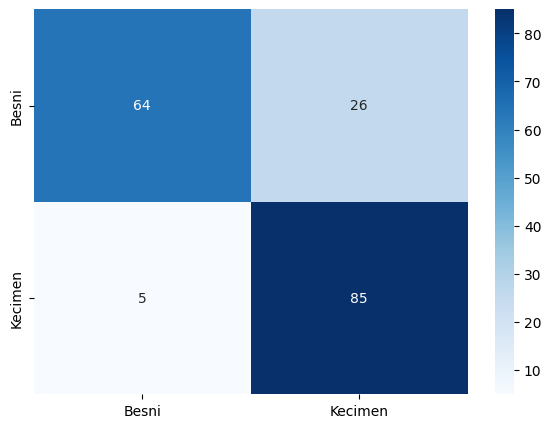

In [ ]:
plt.figure(figsize = (7,5,))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = label_encoder.classes_, yticklabels = label_encoder.classes_)

## 16. Compare Training and Testing Accuracy

Generate predictions for both the training and testing sets, calculate each accuracy score, and print them for comparison. A large gap between training and testing accuracy can indicate overfitting.

In [ ]:
from sklearn.metrics import accuracy_score
y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Testing Accuracy:", test_accuracy)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)
#

Testing Accuracy: 0.8277777777777777
Training Accuracy: 0.8375
